In [1]:
from astropy.io import ascii
from astropy import units as u
from astropy.coordinates import SkyCoord
from gammapy.stats import WStatCountsStatistic
import numpy as np
from gammapy.modeling.models import PowerLawSpectralModel, LogParabolaSpectralModel
import os
import sys
from default_config import DEFAULT_CONFIG
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table
import naima
from main.models import HadronicModel, lnprior_HadronicModel, LeptonicModel, lnprior_LeptonicModel
from main.utils import get_BIC, get_parameters, plot_hadronic_model, plot_multi_instrument
from naima.models import ExponentialCutoffPowerLaw, BrokenPowerLaw, LogParabola, PionDecay, PowerLaw, InverseCompton, Synchrotron

# Go one directory up (to project root) and add it to Python’s search path
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

default_params_HadronicModel = {
    "ECPL": {
        "p0": np.array([36, 2, np.log10(20)]),
        "labels": ["log10(norm)", "alpha", "log10(cutoff_energy)"],
    },
    "BPL": {
        "p0": np.array([26, 2, 0.8, 1.0]),
        "labels": ["log10(norm)", "alpha", "beta", "log10(break_energy)"],
    },
}

default_params_LeptonicModel = {
    "ECPL": {
        "p0": np.array([30, 1.0, 0.3]),
        "labels": ["log10(norm)", "alpha", "log10(cutoff_energy)"],
    },
    "BPL": {
        "p0": np.array([35, 2.5, 1.2, 1.0]),
        "labels": ["log10(norm)", "alpha", "beta", "log10(break_energy)"],
    },
}    



/nevis/ged/share/src/conda_envs/vegas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fermi_data1 = ascii.read('datafiles/4fgl-fermi_above100MeV.dat')
fermi_data2 = ascii.read('datafiles/4fgl-fermi_magichotspot.dat')
fermi_old = ascii.read('datafiles/Fermi_Total.dat')
magic_old = ascii.read('datafiles/MAGIC_Total.dat')
fermi_hotspot = ascii.read("datafiles/Data_points_Fermi_Gaussian.dat")
magic_hotspot = ascii.read("datafiles/Data_points_MAGIC_Gaussian.dat")
veritas_ruo_all = ascii.read('datafiles/naima_VERITAS_ED_v2.dat')
veritas_ruo_arc = ascii.read('datafiles/naima_VERITAS_Arc.dat')
veritas_ruo_hotspot = ascii.read('datafiles/naima_VERITAS_MAGIC.dat')
veritas_ruo_shell = ascii.read('datafiles/naima_VERITAS_Shell.dat')
veritas_vegas_data = ascii.read('datafiles/VERITAS_vegas_4T.dat')
veritas_vegas_hotspot = ascii.read('datafiles/VERITAS_vegas_hotspot.dat')
hawc_data  = ascii.read('datafiles/HAWC_correctformatdata_v2.dat')
xray_data  = ascii.read('datafiles/xray.dat')
radio_data = ascii.read('datafiles/radio.dat')

fermi_data1['ul'] = fermi_data1['ul'].astype(bool)
fermi_data2['ul'] = fermi_data2['ul'].astype(bool)
fermi_hotspot['ul'] = fermi_hotspot['ul'].astype(bool)
fermi_old['ul'] = fermi_old['ul'].astype(bool)
hawc_data['ul'] = hawc_data['ul'].astype(bool)
veritas_ruo_all['ul'] = veritas_ruo_all['ul'].astype(bool)
veritas_vegas_data['ul'] = veritas_vegas_data['ul'].astype(bool)
veritas_vegas_hotspot['ul'] = veritas_vegas_hotspot['ul'].astype(bool)
# new fermi data
#fit_dic = {'Fermi-LAT_Above100MeV (preliminary)':fermi_data1, 'Fermi-LAT_Above10GeV (preliminary)':fermi_data2, 'HAWC (preliminary)': hawc_data, 'VERITAS (EventDisplay)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data}

# old fermi & magic data without hawc
#fit_dic = {'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
#           'VERITAS (ED & Matrix)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data}

# old fermi & magic data with new hawc data
fit_dic = {'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
           'VERITAS (VEGAS)': veritas_vegas_data, 'HAWC (preliminary)': hawc_data, 'X-ray': xray_data}

#fit_dic = {'Fermi-LAT (2023)':fermi_hotspot, 'MAGIC (2023)': magic_hotspot, 'X-ray': xray_data, 'Radio': radio_data,
#           'VERITAS (ED & Matrix)': veritas_ruo_hotspot, 'VERITAS (VEGAS)': veritas_vegas_hotspot}


## Convert Flux to SED

In [3]:
def add_energy_from_edges(tbl,
                          lo_candidates=("energy_edge_lo", "energy_lo", "emin", "e_min", "EBinLowEdge", "Emin"),
                          hi_candidates=("energy_edge_hi", "energy_hi", "emax", "e_max", "EBinHiEdge", "Emax"),
                          method="log",          # "log" or "linear"
                          energy_unit=u.TeV,     # used if edges have no units
                          outcol="energy"):
    """
    Create `outcol` (default: 'energy') from low/high bin edges in an astropy Table.

    Parameters
    ----------
    tbl : astropy.table.Table
    method : str
        "log" -> sqrt(E_lo * E_hi) (geometric mean), preferred
        "linear" -> 0.5*(E_lo + E_hi)
    energy_unit : astropy.unit.Unit
        Used only if edge columns are unitless
    """

    def _first_existing(cands):
        for c in cands:
            if c in tbl.colnames:
                return c
        return None

    lo = _first_existing(lo_candidates)
    hi = _first_existing(hi_candidates)

    if lo is None or hi is None:
        raise KeyError(
            f"Could not find both edge columns. Found lo={lo}, hi={hi}. Available: {tbl.colnames}"
        )

    Elo = tbl[lo]
    Ehi = tbl[hi]

    # Attach units if missing
    if getattr(Elo, "unit", None) is None:
        Elo = Elo * energy_unit
    else:
        Elo = Elo.quantity.to(energy_unit)

    if getattr(Ehi, "unit", None) is None:
        Ehi = Ehi * energy_unit
    else:
        Ehi = Ehi.quantity.to(energy_unit)

    # Safety: avoid non-positive values in log-centering
    if method == "log":
        if np.any(Elo <= 0) or np.any(Ehi <= 0):
            raise ValueError("Non-positive energy edges encountered; cannot use log-centering.")
        E = np.sqrt(Elo * Ehi)
    elif method == "linear":
        E = 0.5 * (Elo + Ehi)
    else:
        raise ValueError("method must be 'log' or 'linear'")

    tbl[outcol] = E.to(energy_unit)

    # Optional extras that can be handy later
    tbl["energy_width"] = (Ehi - Elo).to(energy_unit)
    tbl["energy_edge_lo"] = Elo.to(energy_unit)
    tbl["energy_edge_hi"] = Ehi.to(energy_unit)

    return tbl

In [4]:
for name, tbl in fit_dic.items():
    if "energy" not in tbl.colnames:
        fit_dic[name] = add_energy_from_edges(tbl, method="log", energy_unit=u.TeV)

In [5]:
for k, t in fit_dic.items():
    print(k, t["flux"].unit, t["flux"].unit.physical_type)

Fermi-LAT (2023) eV / (s cm2) energy flux/flux/irradiance
MAGIC (2023) eV / (s cm2) energy flux/flux/irradiance
VERITAS (VEGAS) 1 / (TeV s cm2) differential flux
HAWC (preliminary) TeV / (s cm2) energy flux/flux/irradiance
X-ray erg / (s cm2) energy flux/flux/irradiance


In [6]:
def convert_to_sed(table, target=u.TeV/(u.cm**2*u.s), energy_unit=u.TeV):
    """
    Convert table['flux'] to SED (E^2 dN/dE) and standardize to `target`.
    - If flux already SED-like: just convert units to target.
    - If flux is differential flux: compute sed = E^2 * flux.
    Also forces table['energy'] to be a real energy Quantity.
    """
    t = table.copy()

    # --- Force energy to be an energy quantity ---
    E = t["energy"].quantity if hasattr(t["energy"], "quantity") else t["energy"] * energy_unit

    # If energy column has a bogus unit (e.g. energy flux), strip and reattach:
    if hasattr(E, "unit"):
        if E.unit.physical_type != "energy":
            # interpret stored values as numeric energies in `energy_unit`
            E = u.Quantity(t["energy"].data, energy_unit)
    else:
        E = u.Quantity(t["energy"], energy_unit)

    E = E.to(energy_unit)
    t["energy"] = E  # overwrite with corrected energy column

    # --- Get flux as a Quantity ---
    F = t["flux"].quantity if hasattr(t["flux"], "quantity") else u.Quantity(t["flux"], target)

    # Case 1: already SED-like (energy flux / power per area)
    if F.unit.physical_type in ("energy flux", "flux", "irradiance", "power"):
        t["flux"] = F.to(target)

        if "flux_error" in t.colnames:
            Fe = t["flux_error"].quantity
            t["flux_error"] = Fe.to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = t["flux_error_lo"].quantity.to(target)
            t["flux_error_hi"] = t["flux_error_hi"].quantity.to(target)

        return t

    # Case 2: differential flux -> SED
    if F.unit.physical_type == "differential flux":
        sed = (E**2 * F).to(target)
        t["flux"] = sed

        if "flux_error" in t.colnames:
            t["flux_error"] = (E**2 * t["flux_error"].quantity).to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = (E**2 * t["flux_error_lo"].quantity).to(target)
            t["flux_error_hi"] = (E**2 * t["flux_error_hi"].quantity).to(target)

        return t

    raise ValueError(f"Unrecognized flux physical_type: {F.unit.physical_type} (unit={F.unit})")


In [7]:
for name, table in fit_dic.items():
    fit_dic[name] = convert_to_sed(table)
    print(name, fit_dic[name]["flux"].unit)

Fermi-LAT (2023) TeV / (s cm2)
MAGIC (2023) TeV / (s cm2)
VERITAS (VEGAS) TeV / (s cm2)
HAWC (preliminary) TeV / (s cm2)
X-ray TeV / (s cm2)


# LHAASO data

In [8]:
wcda_pl = PowerLawSpectralModel(index = 2.91*u.Unit(''), 
                                    amplitude=2.36*1e-13 * u.Unit('TeV-1 cm-2 s-1'),
                                   reference=3*u.TeV)


wcda_pl.covariance = np.array([[np.square(0.06), 0, 0],\
                               [0, np.square(0.16*1e-13), 0], [0,0,0]])





km2a_pl = PowerLawSpectralModel(index = 3.56*u.Unit(''), 
                                    amplitude=0.35*1e-16 * u.Unit('TeV-1 cm-2 s-1'),
                                   reference=50*u.TeV)


km2a_pl.covariance = np.array([[np.square(0.23), 0, 0],\
                               [0, np.square(0.05*1e-16), 0], [0,0,0]])


# Modeling

In [9]:
# --- Power-law model: dN/dE = N0 * (E/E0)^(-Gamma)
def dnde_powerlaw(E, N0, E0, Gamma):
    return N0 * (E / E0) ** (-Gamma)

def e2_dnde(E, K, E0, Gamma):
    return (E**2) * dnde_powerlaw(E, K, E0, Gamma)

def e2_dnde_sigma(E, N0, dN0, E0, Gamma, dGamma):
    """
    1σ for y = E^2 * N0 * (E/E0)^(-Gamma), assuming N0 and Gamma uncorrelated.
    ln y = ln N0 + 2 ln E - Gamma ln(E/E0)  ->  σ_y / y = sqrt( (σ_N0/N0)^2 + (ln(E/E0) σ_Gamma)^2 )
    """ 
    y = e2_dnde(E, N0, E0, Gamma)
    lnEE0 = np.log(E / E0)
    rel2  = (dN0 / N0)**2 + (lnEE0 * dGamma)**2
    return y * np.sqrt(rel2)
    

In [10]:
# datatable construction required for naima modeling
datatable = []
for keys in fit_dic.keys():
    datatable.append(fit_dic[keys])

In [11]:
model_type = "BPL"
gas_density = 2.5 * u.cm**-3
distance = 1.7 * u.kpc
B = 20.0 * u.uG


def LeptonicModel_wrapper(pars, data):
    return LeptonicModel(pars, data, B=B, model_type=model_type, distance=distance)[0]
    # [0] because LeptonicModel returns (model_flux, (eE, eDist), We)

def lnprior_wrapper(pars):
    return lnprior_LeptonicModel(pars, model_type=model_type)

p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    data_sed=True,
    prefit=True,
)


INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [34.21514554  2.5         1.2         1.        ] [naima.core]
INFO:    Initial lnprob(p0): -220.452 [naima.core]
INFO:    New ML parameters : [35.48370126  2.81235955  1.35646636  0.61284027] [naima.core]
INFO:    Maximum lnprob(p0): -36.275 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- -----beta------ log10(break_energy)
  Last ensemble median :      35.5            2.81            1.36            0.613     
  Last ensemble std    :      0.149          0.0176          0.00602          0.003     
  Last ensemble lnprob :  avg: -88.823, max: -36.476

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- -----beta------ log10(break_energy)
  Last ensemble median :      35.5            2.81            1.36 

In [12]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(35.47872016073649), 'err_low': np.float64(0.03498339128059769), 'err_high': np.float64(0.0330027946712903)}, 'alpha': {'median': np.float64(2.818105677270155), 'err_low': np.float64(0.08831975741198983), 'err_high': np.float64(0.06843197298675108)}, 'beta': {'median': np.float64(1.3738790303499924), 'err_low': np.float64(0.057867359554792275), 'err_high': np.float64(0.10559198393526992)}, 'log10(break_energy)': {'median': np.float64(0.6159816966332377), 'err_low': np.float64(0.029839219665824368), 'err_high': np.float64(0.06319303051425396)}}


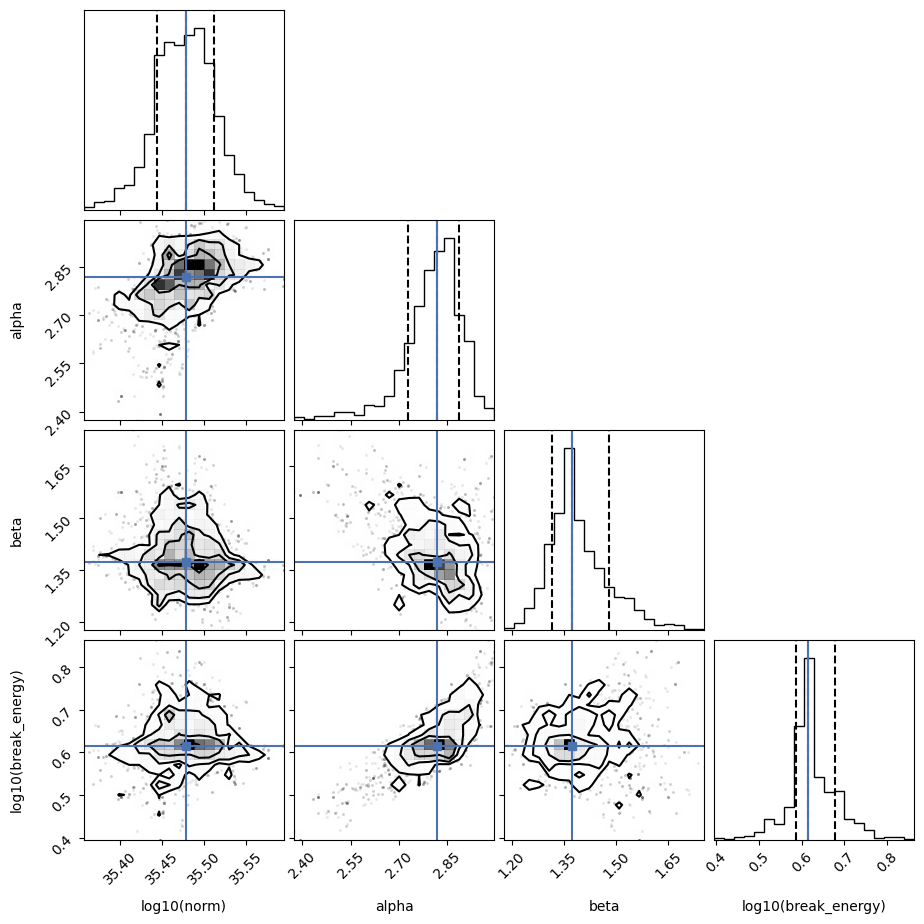

In [13]:
from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)
plt.savefig("corner_leptonic.png")

In [14]:
get_BIC(sampler)

BIC value for model: 86.589


np.float64(86.5892959829113)

In [15]:
#naima.plot_fit(sampler, sed=True, n_samples=100, plotdata=True, plotresiduals=None, e_unit=u.TeV, xlabel=None, ylabel=None, ulim_opts={}, errorbar_opts={})

Electron log10(norm): 35.47872016073649 (-0.03498339128059769 + 0.0330027946712903)
Electron spectral index alpha: 2.818105677270155 (-0.08831975741198983 + 0.06843197298675108)
Electron spectral index beta: 1.3738790303499924 (-0.057867359554792275 + 0.10559198393526992)
Electron log10(break_energy): 0.6159816966332377 (-0.029839219665824368 + 0.06319303051425396)

[Gamma-ray spectrum (Leptonic IC)]
dN/dE (1 TeV): 3.053e-12 1 / (TeV s cm2) (--3.725e-13 1 / (TeV s cm2), +1.861e-14 1 / (TeV s cm2))
E^2 dN/dE (1 TeV): 3.053e-12 TeV / (s cm2) (--3.725e-13 TeV / (s cm2), +1.861e-14 TeV / (s cm2))
Estimated gamma-ray break from modeled IC spectrum: 0.233 TeV (-0.030 TeV, +0.066 TeV)
Gamma-ray spectral index below break Γ1: 1.909 (-0.044, +0.034)
Gamma-ray spectral index above break Γ2: 2.596 (-0.073, +0.087)
Local gamma-ray index @10 TeV: 2.803 (-0.081, +0.096)
Total electron energy We (>1 GeV): 1.678e+50 erg (-7.359e+49 erg, +1.003e+50 erg)


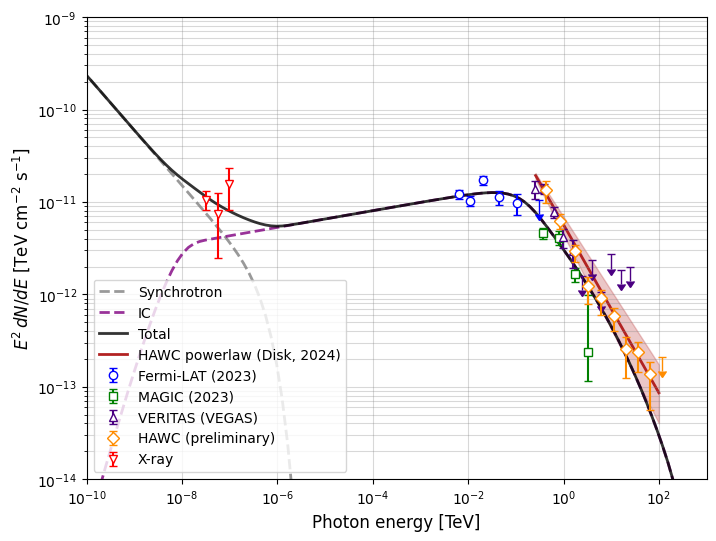

In [17]:
print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
#print(f"Electron log10(cutoff_energy): {MLp_dict['log10(cutoff_energy)']['median']} (-{MLp_dict['log10(cutoff_energy)']['err_low']} + {MLp_dict['log10(cutoff_energy)']['err_high']})")

print(f"Electron spectral index beta: {MLp_dict['beta']['median']} (-{MLp_dict['beta']['err_low']} + {MLp_dict['beta']['err_high']})")
print(f"Electron log10(break_energy): {MLp_dict['log10(break_energy)']['median']} (-{MLp_dict['log10(break_energy)']['err_low']} + {MLp_dict['log10(break_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"], B=B,
                    energy_range=(1e-20, 1e3), label="Leptonic model", color="purple", ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

#ax.set_xlim(left=1e-9)
ax.legend(loc='lower left')
ax.set_xlim(left=1e-10)

#plt.show()
plt.savefig('leptonic_bpl.png')

In [28]:
from naima.plot import find_ML
def get_BIC_per_instrument(sampler, fit_dic, model_func):
    """
    Compute instrument-wise BIC-like values using the global best-fit model.
    """

    ML, ML_params, _, _ = find_ML(sampler, None)
    k = len(ML_params)

    bic_dict = {}

    for inst, data in fit_dic.items():
        cols = set(data.colnames)

        # --- required columns ---
        if "energy" not in cols or "flux" not in cols:
            print(f"Skipping {inst} (missing energy or flux column)")
            continue

        E = data["energy"]
        F = data["flux"]

        # --- symmetric or asymmetric errors ---
        if "flux_error" in cols:
            sigma = data["flux_error"]

        elif "flux_error_lo" in cols and "flux_error_hi" in cols:
            # simple choice: average upper/lower errors
            sigma = 0.5 * (data["flux_error_lo"] + data["flux_error_hi"])

        else:
            print(f"Skipping {inst} (missing flux error columns)")
            continue

        # --- skip upper limits if present ---
        if "ul" in cols:
            mask = ~np.array(data["ul"], dtype=bool)
            E = E[mask]
            F = F[mask]
            sigma = sigma[mask]

        if len(F) == 0:
            print(f"Skipping {inst} (no non-UL points)")
            continue

        model_vals = model_func(ML_params, E)

        # if your model_func returns (model, extra1, extra2), keep only model
        if isinstance(model_vals, tuple):
            model_vals = model_vals[0]

        # Gaussian log-likelihood
        lnL = -0.5 * np.sum(((F - model_vals) / sigma) ** 2)

        n = len(F)
        bic = k * np.log(n) - 2 * lnL
        bic_dict[inst] = bic

    return bic_dict

In [29]:
bic_inst = get_BIC_per_instrument(
    sampler=sampler,
    fit_dic=fit_dic,
    model_func=LeptonicModel_wrapper   # or leptonic
)

for k, v in bic_inst.items():
    print(f"{k}: BIC = {v:.2f}")

Fermi-LAT (2023): BIC = 15.99
MAGIC (2023): BIC = 23.40
VERITAS (VEGAS): BIC = 39.63
HAWC (preliminary): BIC = 26.33


In [1]:
from astropy.io import ascii
from astropy import units as u
from astropy.coordinates import SkyCoord
from gammapy.stats import WStatCountsStatistic
import numpy as np
from gammapy.modeling.models import PowerLawSpectralModel, LogParabolaSpectralModel
import os
import sys
from default_config import DEFAULT_CONFIG
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table
import naima
from main.models import HadronicModel, lnprior_HadronicModel
from main.models import LeptonicModel, lnprior_LeptonicModel
from main.utils import get_BIC, get_parameters, plot_hadronic_model, plot_multi_instrument
from naima.models import ExponentialCutoffPowerLaw, BrokenPowerLaw, LogParabola, PionDecay, PowerLaw, InverseCompton, Synchrotron

# Go one directory up (to project root) and add it to Python’s search path
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

fermi_data1 = ascii.read('datafiles/4fgl-fermi_above100MeV.dat')
fermi_data2 = ascii.read('datafiles/4fgl-fermi_magichotspot.dat')
fermi_old = ascii.read('datafiles/Fermi_Total.dat')
magic_old = ascii.read('datafiles/MAGIC_Total.dat')
fermi_hotspot = ascii.read("datafiles/Data_points_Fermi_Gaussian.dat")
magic_hotspot = ascii.read("datafiles/Data_points_MAGIC_Gaussian.dat")
veritas_ruo_all = ascii.read('datafiles/naima_VERITAS_ED_v2.dat')
veritas_ruo_arc = ascii.read('datafiles/naima_VERITAS_Arc.dat')
veritas_ruo_hotspot = ascii.read('datafiles/naima_VERITAS_MAGIC.dat')
veritas_ruo_shell = ascii.read('datafiles/naima_VERITAS_Shell.dat')
veritas_vegas_data = ascii.read('datafiles/VERITAS_vegas_4T.dat')
veritas_vegas_hotspot = ascii.read('datafiles/VERITAS_vegas_hotspot.dat')
hawc_data  = ascii.read('datafiles/HAWC_correctformatdata_v2.dat')
xray_data  = ascii.read('datafiles/xray.dat')
radio_data = ascii.read('datafiles/radio.dat')

fermi_data1['ul'] = fermi_data1['ul'].astype(bool)
fermi_data2['ul'] = fermi_data2['ul'].astype(bool)
fermi_hotspot['ul'] = fermi_hotspot['ul'].astype(bool)
fermi_old['ul'] = fermi_old['ul'].astype(bool)
hawc_data['ul'] = hawc_data['ul'].astype(bool)
veritas_ruo_all['ul'] = veritas_ruo_all['ul'].astype(bool)
veritas_vegas_data['ul'] = veritas_vegas_data['ul'].astype(bool)
veritas_vegas_hotspot['ul'] = veritas_vegas_hotspot['ul'].astype(bool)


/nevis/ged/share/src/conda_envs/vegas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fit_dic = {'Fermi-LAT (2023)':fermi_hotspot, 'MAGIC (2023)': magic_hotspot, 'X-ray': xray_data, 'VERITAS (VEGAS)': veritas_vegas_hotspot}



In [4]:
def add_energy_from_edges(tbl,
                          lo_candidates=("energy_edge_lo", "energy_lo", "emin", "e_min", "EBinLowEdge", "Emin"),
                          hi_candidates=("energy_edge_hi", "energy_hi", "emax", "e_max", "EBinHiEdge", "Emax"),
                          method="log",          # "log" or "linear"
                          energy_unit=u.TeV,     # used if edges have no units
                          outcol="energy"):
    """
    Create `outcol` (default: 'energy') from low/high bin edges in an astropy Table.

    Parameters
    ----------
    tbl : astropy.table.Table
    method : str
        "log" -> sqrt(E_lo * E_hi) (geometric mean), preferred
        "linear" -> 0.5*(E_lo + E_hi)
    energy_unit : astropy.unit.Unit
        Used only if edge columns are unitless
    """

    def _first_existing(cands):
        for c in cands:
            if c in tbl.colnames:
                return c
        return None

    lo = _first_existing(lo_candidates)
    hi = _first_existing(hi_candidates)

    if lo is None or hi is None:
        raise KeyError(
            f"Could not find both edge columns. Found lo={lo}, hi={hi}. Available: {tbl.colnames}"
        )

    Elo = tbl[lo]
    Ehi = tbl[hi]

    # Attach units if missing
    if getattr(Elo, "unit", None) is None:
        Elo = Elo * energy_unit
    else:
        Elo = Elo.quantity.to(energy_unit)

    if getattr(Ehi, "unit", None) is None:
        Ehi = Ehi * energy_unit
    else:
        Ehi = Ehi.quantity.to(energy_unit)

    # Safety: avoid non-positive values in log-centering
    if method == "log":
        if np.any(Elo <= 0) or np.any(Ehi <= 0):
            raise ValueError("Non-positive energy edges encountered; cannot use log-centering.")
        E = np.sqrt(Elo * Ehi)
    elif method == "linear":
        E = 0.5 * (Elo + Ehi)
    else:
        raise ValueError("method must be 'log' or 'linear'")

    tbl[outcol] = E.to(energy_unit)

    # Optional extras that can be handy later
    tbl["energy_width"] = (Ehi - Elo).to(energy_unit)
    tbl["energy_edge_lo"] = Elo.to(energy_unit)
    tbl["energy_edge_hi"] = Ehi.to(energy_unit)

    return tbl

for name, tbl in fit_dic.items():
    if "energy" not in tbl.colnames:
        fit_dic[name] = add_energy_from_edges(tbl, method="log", energy_unit=u.TeV)

def convert_to_sed(table, target=u.TeV/(u.cm**2*u.s), energy_unit=u.TeV):
    """
    Convert table['flux'] to SED (E^2 dN/dE) and standardize to `target`.
    - If flux already SED-like: just convert units to target.
    - If flux is differential flux: compute sed = E^2 * flux.
    Also forces table['energy'] to be a real energy Quantity.
    """
    t = table.copy()

    # --- Force energy to be an energy quantity ---
    E = t["energy"].quantity if hasattr(t["energy"], "quantity") else t["energy"] * energy_unit

    # If energy column has a bogus unit (e.g. energy flux), strip and reattach:
    if hasattr(E, "unit"):
        if E.unit.physical_type != "energy":
            # interpret stored values as numeric energies in `energy_unit`
            E = u.Quantity(t["energy"].data, energy_unit)
    else:
        E = u.Quantity(t["energy"], energy_unit)

    E = E.to(energy_unit)
    t["energy"] = E  # overwrite with corrected energy column

    # --- Get flux as a Quantity ---
    F = t["flux"].quantity if hasattr(t["flux"], "quantity") else u.Quantity(t["flux"], target)

    # Case 1: already SED-like (energy flux / power per area)
    if F.unit.physical_type in ("energy flux", "flux", "irradiance", "power"):
        t["flux"] = F.to(target)

        if "flux_error" in t.colnames:
            Fe = t["flux_error"].quantity
            t["flux_error"] = Fe.to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = t["flux_error_lo"].quantity.to(target)
            t["flux_error_hi"] = t["flux_error_hi"].quantity.to(target)

        return t

    # Case 2: differential flux -> SED
    if F.unit.physical_type == "differential flux":
        sed = (E**2 * F).to(target)
        t["flux"] = sed

        if "flux_error" in t.colnames:
            t["flux_error"] = (E**2 * t["flux_error"].quantity).to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = (E**2 * t["flux_error_lo"].quantity).to(target)
            t["flux_error_hi"] = (E**2 * t["flux_error_hi"].quantity).to(target)

        return t

    raise ValueError(f"Unrecognized flux physical_type: {F.unit.physical_type} (unit={F.unit})")

for name, table in fit_dic.items():
    fit_dic[name] = convert_to_sed(table)
    print(name, fit_dic[name]["flux"].unit)

datatable = []
for keys in fit_dic.keys():
    datatable.append(fit_dic[keys])

model_type = "BPL"
gas_density = 2.5 * u.cm**-3
distance = 1.7 * u.kpc
B = 30 * u.uG

def LeptonicModel_wrapper(pars, data):
    return LeptonicModel(pars, data, model_type=model_type, distance=distance, B=B)[0]
    # [0] because LeptonicModel returns (model_flux, (eE, eDist), We)

def lnprior_wrapper(pars):
    return lnprior_LeptonicModel(pars, model_type=model_type)

default_params_LeptonicModel = {
    "ECPL": {
        "p0": np.array([30, 2.0, np.log10(20.0), np.log10(20.0)]),
        "labels": ["log10(norm)", "alpha", "log10(cutoff_energy)", "log10(B_uG)"],
    },
    "BPL": {
        "p0": np.array([30, 1.8, 1.0, np.log10(0.3), np.log10(20.0)]),
        "labels": ["log10(norm)", "alpha", "beta", "log10(break_energy)", "log10(B_uG)"],
    },
}


p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    prefit=True,
)



Fermi-LAT (2023) TeV / (s cm2)
MAGIC (2023) TeV / (s cm2)
X-ray TeV / (s cm2)
VERITAS (VEGAS) TeV / (s cm2)
INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [33.95163035  1.8         1.         -0.52287875  1.30103   ] [naima.core]
INFO:    Initial lnprob(p0): -13.087 [naima.core]
INFO:    New ML parameters : [33.76160904  1.84629885  1.47319564 -0.0701462   1.72839864] [naima.core]
INFO:    Maximum lnprob(p0): -6.624 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- -----beta------ log10(break_energy) --log10(B_uG)--
  Last ensemble median :      33.7            1.85            1.47           -0.0702          1.73      
  Last ensemble std    :      0.134          0.0089          0.00789        0.000335         0.00676    
  Last ensemble lnprob :  avg: -27.189, max: -6.685

Progress of the run: 5 percent (

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(33.75997976632933), 'err_low': np.float64(0.052248823161292535), 'err_high': np.float64(0.048600214659074936)}, 'alpha': {'median': np.float64(1.847557438156206), 'err_low': np.float64(0.08793667798106153), 'err_high': np.float64(0.06626996483610759)}, 'beta': {'median': np.float64(1.4742558452955477), 'err_low': np.float64(0.15040299084220488), 'err_high': np.float64(0.1879344890527872)}, 'log10(break_energy)': {'median': np.float64(-0.06980852544902208), 'err_low': np.float64(0.03992656684774426), 'err_high': np.float64(0.03840186375933955)}, 'log10(B_uG)': {'median': np.float64(1.7092824829035036), 'err_low': np.float64(0.13586596445455412), 'err_high': np.float64(0.1556573909894099)}}
BIC value for model: 29.179
Electron log10(norm): 33.75997976632933 (-0.052248823161292535 + 0.048600214659074936)
Electron spectral index alpha: 1.847557438156206 (-0.08793667798106153 + 0.06626996483610759)
Electron spectr

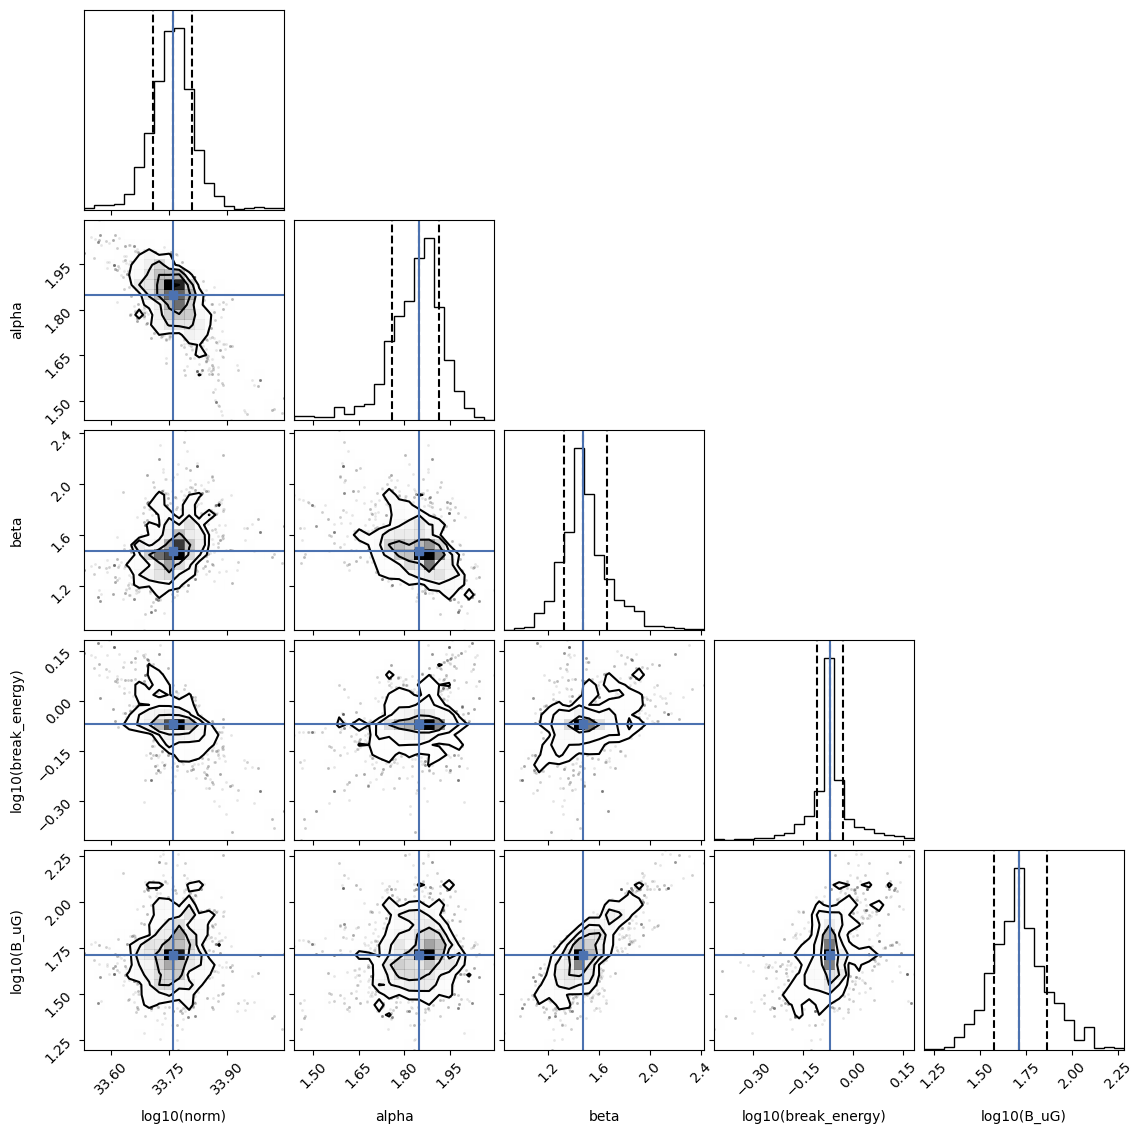

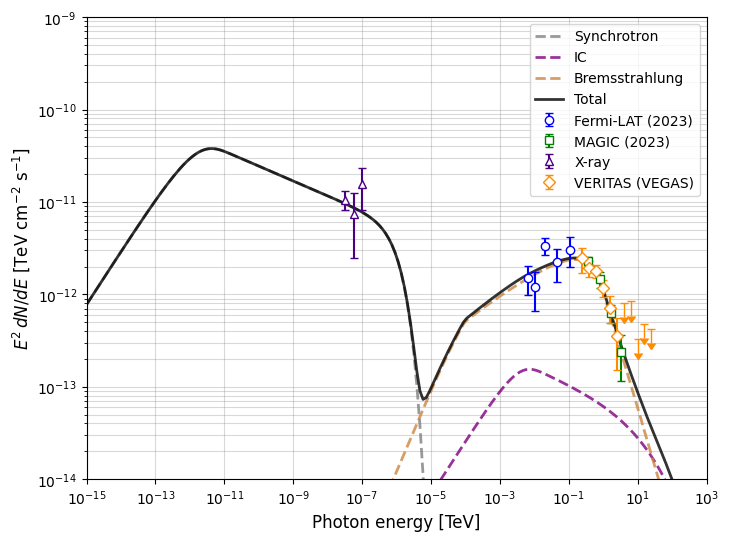

In [5]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

# --- Power-law model: dN/dE = N0 * (E/E0)^(-Gamma)
def dnde_powerlaw(E, N0, E0, Gamma):
    return N0 * (E / E0) ** (-Gamma)

def e2_dnde(E, K, E0, Gamma):
    return (E**2) * dnde_powerlaw(E, K, E0, Gamma)

def e2_dnde_sigma(E, N0, dN0, E0, Gamma, dGamma):
    """
    1σ for y = E^2 * N0 * (E/E0)^(-Gamma), assuming N0 and Gamma uncorrelated.
    ln y = ln N0 + 2 ln E - Gamma ln(E/E0)  ->  σ_y / y = sqrt( (σ_N0/N0)^2 + (ln(E/E0) σ_Gamma)^2 )
    """ 
    y = e2_dnde(E, N0, E0, Gamma)
    lnEE0 = np.log(E / E0)
    rel2  = (dN0 / N0)**2 + (lnEE0 * dGamma)**2
    return y * np.sqrt(rel2)
    

from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)

get_BIC(sampler)

print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
print(f"Electron spectral index beta: {MLp_dict['beta']['median']} (-{MLp_dict['beta']['err_low']} + {MLp_dict['beta']['err_high']})")
print(f"Electron log10(break_energy): {MLp_dict['log10(break_energy)']['median']} (-{MLp_dict['log10(break_energy)']['err_low']} + {MLp_dict['log10(break_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"],
    label="Leptonic model", energy_range=(1e-15, 1e3),
    color="purple", ax = ax, show=False)


ax.legend()

plt.show()
#plt.savefig('leptonic_ecpl.png')

In [2]:
# No x-ray
fit_dic = {'Fermi-LAT (2023)':fermi_hotspot, 'MAGIC (2023)': magic_hotspot, 
           'VERITAS (ED & Matrix)': veritas_ruo_hotspot, 'VERITAS (VEGAS)': veritas_vegas_hotspot}

def add_energy_from_edges(tbl,
                          lo_candidates=("energy_edge_lo", "energy_lo", "emin", "e_min", "EBinLowEdge", "Emin"),
                          hi_candidates=("energy_edge_hi", "energy_hi", "emax", "e_max", "EBinHiEdge", "Emax"),
                          method="log",          # "log" or "linear"
                          energy_unit=u.TeV,     # used if edges have no units
                          outcol="energy"):
    """
    Create `outcol` (default: 'energy') from low/high bin edges in an astropy Table.

    Parameters
    ----------
    tbl : astropy.table.Table
    method : str
        "log" -> sqrt(E_lo * E_hi) (geometric mean), preferred
        "linear" -> 0.5*(E_lo + E_hi)
    energy_unit : astropy.unit.Unit
        Used only if edge columns are unitless
    """

    def _first_existing(cands):
        for c in cands:
            if c in tbl.colnames:
                return c
        return None

    lo = _first_existing(lo_candidates)
    hi = _first_existing(hi_candidates)

    if lo is None or hi is None:
        raise KeyError(
            f"Could not find both edge columns. Found lo={lo}, hi={hi}. Available: {tbl.colnames}"
        )

    Elo = tbl[lo]
    Ehi = tbl[hi]

    # Attach units if missing
    if getattr(Elo, "unit", None) is None:
        Elo = Elo * energy_unit
    else:
        Elo = Elo.quantity.to(energy_unit)

    if getattr(Ehi, "unit", None) is None:
        Ehi = Ehi * energy_unit
    else:
        Ehi = Ehi.quantity.to(energy_unit)

    # Safety: avoid non-positive values in log-centering
    if method == "log":
        if np.any(Elo <= 0) or np.any(Ehi <= 0):
            raise ValueError("Non-positive energy edges encountered; cannot use log-centering.")
        E = np.sqrt(Elo * Ehi)
    elif method == "linear":
        E = 0.5 * (Elo + Ehi)
    else:
        raise ValueError("method must be 'log' or 'linear'")

    tbl[outcol] = E.to(energy_unit)

    # Optional extras that can be handy later
    tbl["energy_width"] = (Ehi - Elo).to(energy_unit)
    tbl["energy_edge_lo"] = Elo.to(energy_unit)
    tbl["energy_edge_hi"] = Ehi.to(energy_unit)

    return tbl

for name, tbl in fit_dic.items():
    if "energy" not in tbl.colnames:
        fit_dic[name] = add_energy_from_edges(tbl, method="log", energy_unit=u.TeV)

def convert_to_sed(table, target=u.TeV/(u.cm**2*u.s), energy_unit=u.TeV):
    """
    Convert table['flux'] to SED (E^2 dN/dE) and standardize to `target`.
    - If flux already SED-like: just convert units to target.
    - If flux is differential flux: compute sed = E^2 * flux.
    Also forces table['energy'] to be a real energy Quantity.
    """
    t = table.copy()

    # --- Force energy to be an energy quantity ---
    E = t["energy"].quantity if hasattr(t["energy"], "quantity") else t["energy"] * energy_unit

    # If energy column has a bogus unit (e.g. energy flux), strip and reattach:
    if hasattr(E, "unit"):
        if E.unit.physical_type != "energy":
            # interpret stored values as numeric energies in `energy_unit`
            E = u.Quantity(t["energy"].data, energy_unit)
    else:
        E = u.Quantity(t["energy"], energy_unit)

    E = E.to(energy_unit)
    t["energy"] = E  # overwrite with corrected energy column

    # --- Get flux as a Quantity ---
    F = t["flux"].quantity if hasattr(t["flux"], "quantity") else u.Quantity(t["flux"], target)

    # Case 1: already SED-like (energy flux / power per area)
    if F.unit.physical_type in ("energy flux", "flux", "irradiance", "power"):
        t["flux"] = F.to(target)

        if "flux_error" in t.colnames:
            Fe = t["flux_error"].quantity
            t["flux_error"] = Fe.to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = t["flux_error_lo"].quantity.to(target)
            t["flux_error_hi"] = t["flux_error_hi"].quantity.to(target)

        return t

    # Case 2: differential flux -> SED
    if F.unit.physical_type == "differential flux":
        sed = (E**2 * F).to(target)
        t["flux"] = sed

        if "flux_error" in t.colnames:
            t["flux_error"] = (E**2 * t["flux_error"].quantity).to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = (E**2 * t["flux_error_lo"].quantity).to(target)
            t["flux_error_hi"] = (E**2 * t["flux_error_hi"].quantity).to(target)

        return t

    raise ValueError(f"Unrecognized flux physical_type: {F.unit.physical_type} (unit={F.unit})")

for name, table in fit_dic.items():
    fit_dic[name] = convert_to_sed(table)
    print(name, fit_dic[name]["flux"].unit)

datatable = []
for keys in fit_dic.keys():
    datatable.append(fit_dic[keys])

model_type = "ECPL"
gas_density = 2.5 * u.cm**-3
distance = 1.7 * u.kpc

def LeptonicModel_wrapper(pars, data):
    return LeptonicModel(pars, data, model_type=model_type, distance=distance)[0]
    # [0] because LeptonicModel returns (model_flux, (eE, eDist), We)

def lnprior_wrapper(pars):
    return lnprior_LeptonicModel(pars, model_type=model_type)


p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    prefit=True,
)



Fermi-LAT (2023) TeV / (s cm2)
MAGIC (2023) TeV / (s cm2)
VERITAS (ED & Matrix) TeV / (s cm2)
VERITAS (VEGAS) TeV / (s cm2)
INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [34.47841345  2.5         1.6       ] [naima.core]
INFO:    Initial lnprob(p0): -inf [naima.core]


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter

Burning in the 32 walkers with 20 steps...


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter


Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :       36             2.57            1.61      
  Last ensemble std    :      2.86            0.26            0.168     
  Last ensemble lnprob :  avg: -inf, max: -inf

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :       36             2.57            1.61      
  Last ensemble std    :      2.86            0.26            0.168     
  Last ensemble lnprob :  avg: -inf, max: -inf


...

/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter


Progress of the run: 90 percent (90 of 100 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :       36             2.57            1.61      
  Last ensemble std    :      2.86            0.26            0.168     
  Last ensemble lnprob :  avg: -inf, max: -inf


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter


Progress of the run: 95 percent (95 of 100 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :       36             2.57            1.61      
  Last ensemble std    :      2.86            0.26            0.168     
  Last ensemble lnprob :  avg: -inf, max: -inf


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(36.47094180053398), 'err_low': np.float64(3.4147988522350943), 'err_high': np.float64(3.5191102353106345)}, 'alpha': {'median': np.float64(2.4309475660938147), 'err_low': np.float64(0.1645421695284739), 'err_high': np.float64(0.19961044500775182)}, 'beta': {'median': np.float64(1.6016919626086168), 'err_low': np.float64(0.13019635721237766), 'err_high': np.float64(0.08999425757024437)}, 'log10(break_energy)': {'median': np.float64(0.8044150269871289), 'err_low': np.float64(0.06526806665991713), 'err_high': np.float64(0.05790040199803714)}}
BIC value for model: inf
Electron log10(norm): 36.47094180053398 (-3.4147988522350943 + 3.5191102353106345)
Electron spectral index alpha: 2.4309475660938147 (-0.1645421695284739 + 0.19961044500775182)
Electron spectral index beta: 1.6016919626086168 (-0.13019635721237766 + 0.08999425757024437)
Electron log10(break_energy): 0.8044150269871289 (-0.06526806665991713 + 0.05790

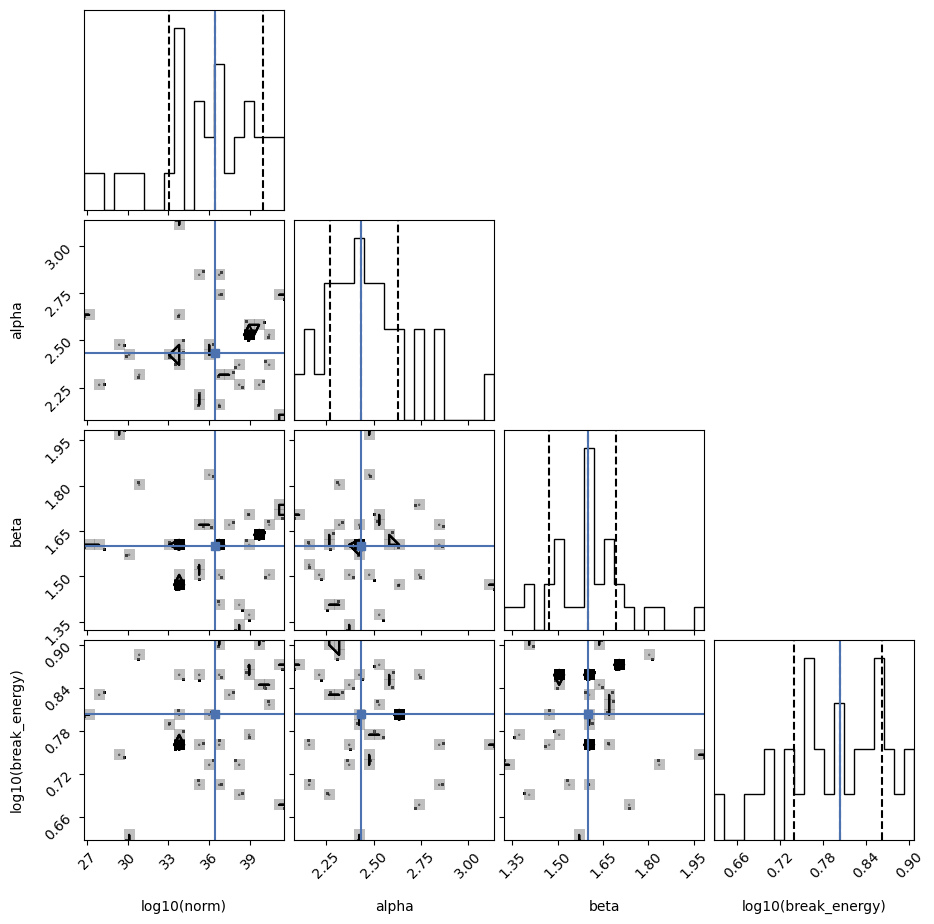

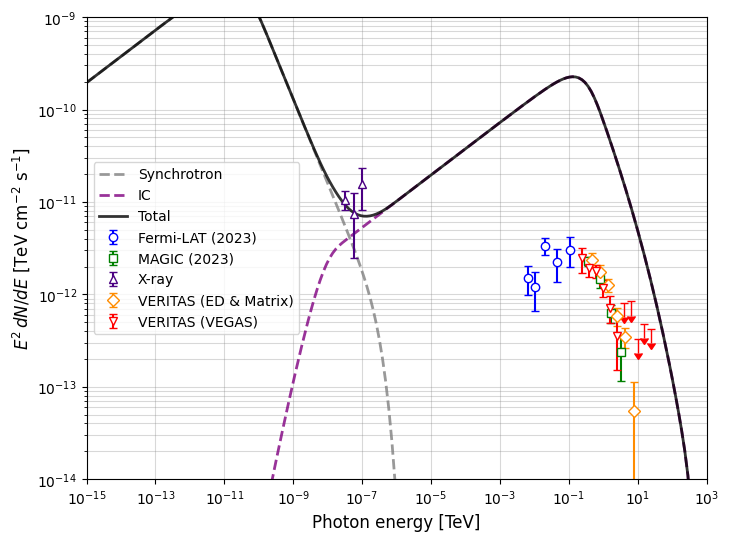

In [34]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

# --- Power-law model: dN/dE = N0 * (E/E0)^(-Gamma)
def dnde_powerlaw(E, N0, E0, Gamma):
    return N0 * (E / E0) ** (-Gamma)

def e2_dnde(E, K, E0, Gamma):
    return (E**2) * dnde_powerlaw(E, K, E0, Gamma)

def e2_dnde_sigma(E, N0, dN0, E0, Gamma, dGamma):
    """
    1σ for y = E^2 * N0 * (E/E0)^(-Gamma), assuming N0 and Gamma uncorrelated.
    ln y = ln N0 + 2 ln E - Gamma ln(E/E0)  ->  σ_y / y = sqrt( (σ_N0/N0)^2 + (ln(E/E0) σ_Gamma)^2 )
    """ 
    y = e2_dnde(E, N0, E0, Gamma)
    lnEE0 = np.log(E / E0)
    rel2  = (dN0 / N0)**2 + (lnEE0 * dGamma)**2
    return y * np.sqrt(rel2)
    

from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)

get_BIC(sampler)

print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
#print(f"Electron log10(cutoff_energy): {MLp_dict['log10(cutoff_energy)']['median']} (-{MLp_dict['log10(cutoff_energy)']['err_low']} + {MLp_dict['log10(cutoff_energy)']['err_high']})")
print(f"Electron spectral index beta: {MLp_dict['beta']['median']} (-{MLp_dict['beta']['err_low']} + {MLp_dict['beta']['err_high']})")
print(f"Electron log10(break_energy): {MLp_dict['log10(break_energy)']['median']} (-{MLp_dict['log10(break_energy)']['err_low']} + {MLp_dict['log10(break_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"],
    label="Leptonic IC model", energy_range=(1e-15, 1e3),
    color="purple", ax = ax, show=False)


ax.legend()

plt.show()
#plt.savefig('leptonic_ecpl.png')

In [5]:
def ElectronSynIC(pars, data):
    # Match parameters to ECPL properties, and give them the appropriate units
    amplitude = 10 ** pars[0] / u.eV
    alpha = pars[1]
    e_cutoff = (10 ** pars[2]) * u.TeV
    B = pars[3] * u.uG

    # Initialize instances of the particle distribution and radiative models
    ECPL = ExponentialCutoffPowerLaw(amplitude, 10.0 * u.TeV, alpha, e_cutoff)
    # Compute IC on CMB and on a FIR component with values from GALPROP for the
    # position of RXJ1713
    IC = InverseCompton(
        ECPL,
        seed_photon_fields=[
            "CMB"
        ],
        Eemin=10 * u.GeV,
    )
    SYN = Synchrotron(ECPL, B=B)

    # compute flux at the energies given in data['energy']
    model = IC.flux(data, distance=1.5 * u.kpc) + SYN.flux(data, distance=1.5 * u.kpc)

    # The first array returned will be compared to the observed spectrum for
    # fitting. All subsequent objects will be stored in the sampler metadata
    # blobs.
    return model, IC.compute_We(Eemin=1 * u.TeV)


def lnprior(pars):
    """
    Return probability of parameter values according to prior knowledge.
    Parameter limits should be done here through uniform prior ditributions
    """
    # Limit norm and B to be positive
    logprob = (
        naima.uniform_prior(pars[0], 0.0, np.inf)
        + naima.uniform_prior(pars[1], -1, 5) + naima.uniform_prior(pars[2], -1, 5)
        + naima.uniform_prior(pars[3], 0, np.inf)
    )

    return logprob

In [6]:
B0 = 1 
p0 = np.array((33, 2.5, np.log10(48.0), B0))
labels = ["log10(norm)", "index", "log10(cutoff)", "B"]

In [7]:
sampler, pos = naima.run_sampler(
        data_table=datatable,
        p0=p0,
        labels=labels,
        model=ElectronSynIC,
        prior=lnprior,
        nwalkers=32,
        nburn=100,
        nrun=20,
        threads=4,
        prefit=True,
        interactive=False,
    )

INFO:astropy:Finding Maximum Likelihood parameters through Nelder-Mead fitting...
INFO:astropy:   Initial parameters: [35.97600826  2.5         1.68124124  1.        ]
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
INFO:astropy:   Initial lnprob(p0): -inf


INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [35.97600826  2.5         1.68124124  1.        ] [naima.core]
INFO:    Initial lnprob(p0): -inf [naima.core]


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter

Burning in the 32 walkers with 100 steps...


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter

...


Progress of the run: 75 percent (15 of 20 steps)
                           --log10(norm)-- -----index----- -log10(cutoff)- -------B-------
  Last ensemble median :      36.6            2.49            1.64            1.01      
  Last ensemble std    :      3.74            0.218           0.16            0.106     
  Last ensemble lnprob :  avg: -inf, max: -inf

Progress of the run: 80 percent (16 of 20 steps)
                           --log10(norm)-- -----index----- -log10(cutoff)- -------B-------
  Last ensemble median :      36.6            2.49            1.64            1.01      
  Last ensemble std    :      3.74            0.218           0.16            0.106     
  Last ensemble lnprob :  avg: -inf, max: -inf


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter


Progress of the run: 85 percent (17 of 20 steps)
                           --log10(norm)-- -----index----- -log10(cutoff)- -------B-------
  Last ensemble median :      36.6            2.49            1.64            1.01      
  Last ensemble std    :      3.74            0.218           0.16            0.106     
  Last ensemble lnprob :  avg: -inf, max: -inf

Progress of the run: 90 percent (18 of 20 steps)
                           --log10(norm)-- -----index----- -log10(cutoff)- -------B-------
  Last ensemble median :      36.6            2.49            1.64            1.01      
  Last ensemble std    :      3.74            0.218           0.16            0.106     
  Last ensemble lnprob :  avg: -inf, max: -inf


/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/nevis/tehanu/home/bihan/.local/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encounter


Progress of the run: 95 percent (19 of 20 steps)
                           --log10(norm)-- -----index----- -log10(cutoff)- -------B-------
  Last ensemble median :      36.6            2.49            1.64            1.01      
  Last ensemble std    :      3.74            0.218           0.16            0.106     
  Last ensemble lnprob :  avg: -inf, max: -inf


Best fit parameters for Hadronic Model:
{'log10(norm)': {'median': np.float64(36.55535528160491), 'err_low': np.float64(3.557636710681109), 'err_high': np.float64(3.043755076789438)}, 'index': {'median': np.float64(2.488461197321384), 'err_low': np.float64(0.18481411287327099), 'err_high': np.float64(0.20497734402318857)}, 'log10(cutoff)': {'median': np.float64(1.6373054373708542), 'err_low': np.float64(0.09654068349659406), 'err_high': np.float64(0.1835755852938763)}, 'B': {'median': np.float64(1.0091606344880217), 'err_low': np.float64(0.10662369490631673), 'err_high': np.float64(0.06484691445351687)}}


TypeError: unhashable type: 'dict'

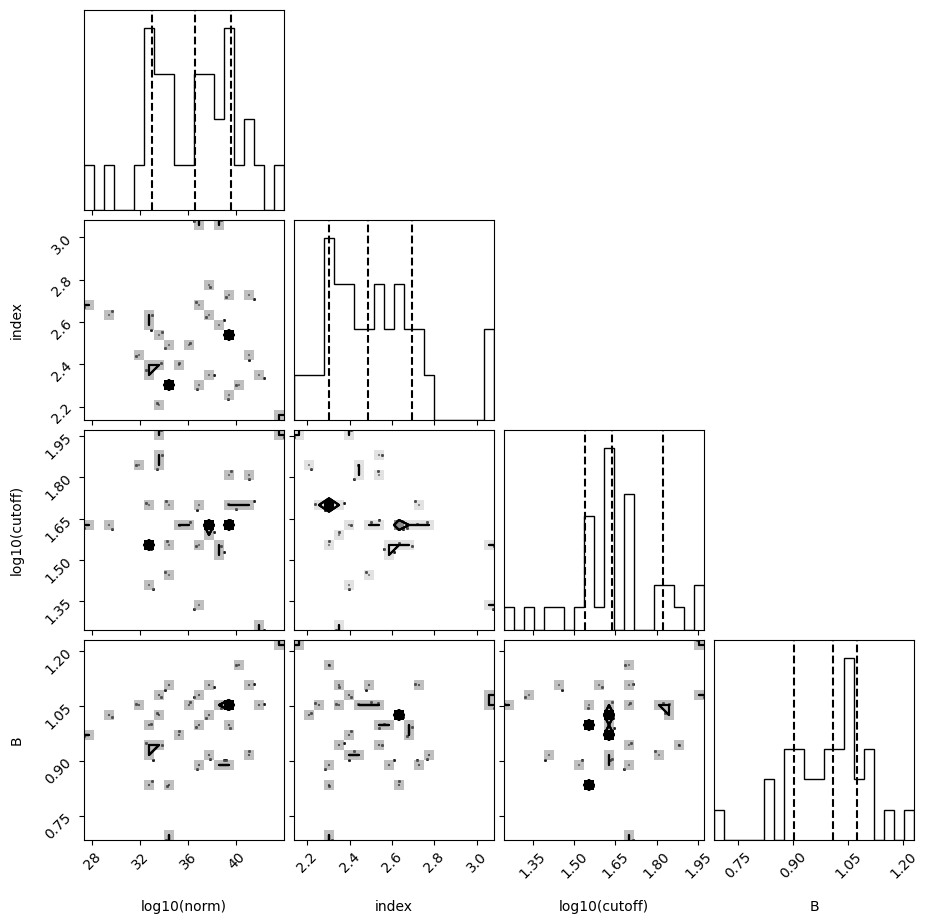

In [8]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Hadronic Model:")
print(MLp_dict)

from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(MLp_dict.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)

TypeError: unsupported operand type(s) for ** or pow(): 'int' and 'dict'

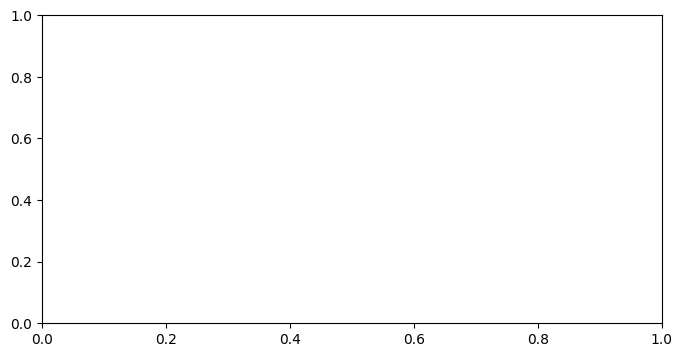

In [9]:
fig,ax = plt.subplots(figsize=(8,4))

amplitude = 10 ** MLp_dict['log10(norm)'] / u.eV
alpha = MLp_dict['index']
e_cutoff = (10 ** MLp_dict['log10(cutoff)']) * u.TeV
B = MLp_dict['B'] * u.uG

distance = 1.5 *u.kpc

ECPL = ExponentialCutoffPowerLaw(amplitude, 10.0 * u.TeV, alpha, e_cutoff)


IC = InverseCompton(
        ECPL,
        seed_photon_fields=[
            "CMB"
        ],
        Eemin=100 * u.GeV,
    )
SYN = Synchrotron(ECPL, B=B)

spectrum_energy = np.logspace(np.log10(1e-16), np.log10(1e3), 200) * u.TeV

sed_syn = SYN.sed(spectrum_energy, distance=distance)
sed_ic = IC.sed(spectrum_energy, distance=distance)


ax.loglog(
            spectrum_energy.to("TeV").value,
            sed_syn.to("erg cm-2 s-1").value,
            lw=1.5,
            ls="--",
            color="blue",
            alpha=0.7,
            label="Synchrotron",
        )


ax.loglog(
            spectrum_energy.to("TeV").value,
            sed_ic.to("erg cm-2 s-1").value,
            lw=1.5,
            ls=":",
            color="red",
            alpha=0.7,
            label="Inverse Compton",
        )



color = ["blue", "green", "red", "gray", "darkorange"]
marker = ["o", "s", "^", "D", "v"]


i = 0
for keys in fit_dic.keys():
    plot_data(
        ax,
        fit_dic[keys],
        color=color[i],
        marker=marker[i],
        energy_unit="TeV",
        flux_unit="erg cm-2 s-1",
        label=keys,
    )
    i += 1


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-14, 1e3)
ax.set_ylim(1e-14, 1e-9)

ax.set_xlabel(r"Photon energy [TeV]", fontsize=12)
ax.set_ylabel(r"$E^2 \, dN/dE$ [erg cm$^{-2}$ s$^{-1}$]", fontsize=12)
ax.grid(which="both", color="gray", alpha=0.3)
ax.legend(frameon=True, facecolor="white", edgecolor="black", ncol=3)

#plt.savefig('IC+SYn.png', bbox_inches='tight')
plt.show()

In [5]:
fit_dic = {'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
           'VERITAS (ED & Matrix)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data, 'HAWC (preliminary)': hawc_data}

In [6]:
import itertools
import matplotlib as mpl

# ============================================================
# Globals used by the sampler wrapper
# ============================================================
_CURRENT_LEP_MODEL_TYPE = "BPL"
_CURRENT_LEP_DISTANCE = 1.7 * u.kpc
_CURRENT_LEP_B = 20.0 * u.uG
_CURRENT_LEP_SEED_FIELDS = ["CMB"]


def LeptonicModel_wrapper(pars, data):
    """
    Thin wrapper around LeptonicModel using global run settings.
    Keeps the sampler call simple and avoids nested local functions.
    """
    return LeptonicModel(
        pars,
        data,
        model_type=_CURRENT_LEP_MODEL_TYPE,
        distance=_CURRENT_LEP_DISTANCE,
        B=_CURRENT_LEP_B,
        seed_photon_fields=_CURRENT_LEP_SEED_FIELDS,
    )


def _set_leptonic_globals(model_type, distance, B, seed_photon_fields):
    global _CURRENT_LEP_MODEL_TYPE, _CURRENT_LEP_DISTANCE, _CURRENT_LEP_B, _CURRENT_LEP_SEED_FIELDS
    _CURRENT_LEP_MODEL_TYPE = model_type
    _CURRENT_LEP_DISTANCE = distance
    _CURRENT_LEP_B = B
    _CURRENT_LEP_SEED_FIELDS = seed_photon_fields


def _extract_medians(params_dict):
    return {key: val["median"] for key, val in params_dict.items()}


def _flatten_params_dict(params_dict, mode="median"):
    flat = {}
    for key, val in params_dict.items():
        if isinstance(val, dict):
            flat[key] = val[mode]
        else:
            flat[key] = val
    return flat


def _format_quantity(q):
    if hasattr(q, "unit"):
        return f"{q.value:g} {q.unit}"
    return str(q)


def compute_leptonic_total_sed(
    params_dict,
    model_type="ECPL",
    distance=1.7 * u.kpc,
    B=20.0 * u.uG,
    seed_photon_fields=None,
    energy_range=(1e-5, 1e3),  # TeV
    ngrid=300,
):
    """
    Compute total leptonic SED = synchrotron + IC on an energy grid.
    Returns (Egrid, sed_total, sed_syn, sed_ic).
    """
    if seed_photon_fields is None:
        seed_photon_fields = ["CMB"]

    Egrid = np.logspace(np.log10(energy_range[0]), np.log10(energy_range[1]), ngrid) * u.TeV
    p = _flatten_params_dict(params_dict, mode="median")
    amplitude = 10 ** p["log10(norm)"] / u.eV

    if model_type.upper() == "ECPL":
        electron_spectrum = ExponentialCutoffPowerLaw(
            amplitude=amplitude,
            e_0=1.0 * u.TeV,
            alpha=p["alpha"],
            e_cutoff=10 ** p["log10(cutoff_energy)"] * u.TeV,
            beta=1.0,
        )
    elif model_type.upper() == "BPL":
        electron_spectrum = BrokenPowerLaw(
            amplitude=amplitude,
            e_0=1.0 * u.TeV,
            e_break=10 ** p["log10(break_energy)"] * u.TeV,
            alpha_1=p["alpha"],
            alpha_2=p["alpha"] + p["beta"],
        )
    else:
        raise ValueError("model_type must be 'ECPL' or 'BPL'")

    syn = Synchrotron(electron_spectrum, B=B)
    ic = InverseCompton(electron_spectrum, seed_photon_fields=seed_photon_fields)

    sed_syn = syn.sed(Egrid, distance=distance)
    sed_ic = ic.sed(Egrid, distance=distance)
    sed_total = sed_syn + sed_ic

    return Egrid, sed_total, sed_syn, sed_ic


def fit_leptonic_spectrum(
    datatable,
    fit_dic,
    p0,
    labels,
    B,
    distance,
    model_type="BPL",
    seed_photon_fields=None,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=1,      # keep 1 in notebooks
    prefit=True,
    data_sed=True,
    make_model_plot=True,
    verbose=True,
):
    """
    Fit one leptonic model for a given B field and distance.
    """

    if seed_photon_fields is None:
        seed_photon_fields = ["CMB"]

    _set_leptonic_globals(
        model_type=model_type,
        distance=distance,
        B=B,
        seed_photon_fields=seed_photon_fields,
    )

    sampler, pos = naima.run_sampler(
        data_table=datatable,
        p0=p0,
        labels=labels,
        model=LeptonicModel_wrapper,
        prior=lambda pars: lnprior_LeptonicModel(pars, model_type=model_type),
        nwalkers=nwalkers,
        nburn=nburn,
        nrun=nrun,
        threads=threads,
        prefit=prefit,
        data_sed=data_sed,
    )

    params_dict = get_parameters(sampler, ML=False)
    medians = _extract_medians(params_dict)
    bic = get_BIC(sampler)

    if verbose:
        print("\n==============================")
        print(f"B={_format_quantity(B)}, distance={_format_quantity(distance)}")
        print("==============================")
        print(params_dict)
        print(f"BIC = {bic:.3f}")

    fig_model, ax_model = None, None
    if make_model_plot:
        fig_model, ax_model = plt.subplots(figsize=(8, 6))

        # this helper from your utils file already plots synch + IC + total + data
        plot_leptonic_model(
            params_dict=params_dict,
            model_type=model_type,
            distance=distance,
            B=B,
            seed_photon_fields=seed_photon_fields,
            ax=ax_model,
            data_dict=fit_dic,
            show=False,
        )

        ax_model.set_title(f"Leptonic fit: B = {_format_quantity(B)}, d = {_format_quantity(distance)}")

    return {
        "B": B,
        "distance": distance,
        "model_type": model_type,
        "seed_photon_fields": seed_photon_fields,
        "sampler": sampler,
        "params_dict": params_dict,
        "medians": medians,
        "bic": bic,
        "fig_model": fig_model,
        "ax_model": ax_model,
    }


def fit_leptonic_grid(
    datatable,
    fit_dic,
    p0,
    labels,
    B_fields,
    distances,
    model_type="BPL",
    seed_photon_fields=None,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=1,
    prefit=True,
    data_sed=True,
    cmap="Greys_r",
    energy_range=(1e-5, 1e3),
    verbose=True,
):
    """
    Loop over B fields and/or distances, fit the same data,
    and generate a single plot with total model curves colored by BIC.
    Darker = better fit (lower BIC).
    """
    if seed_photon_fields is None:
        seed_photon_fields = ["CMB"]

    results = []

    # run all fits
    for B, distance in itertools.product(B_fields, distances):
        res = fit_leptonic_spectrum(
            datatable=datatable,
            fit_dic=fit_dic,
            p0=p0,
            labels=labels,
            B=B,
            distance=distance,
            model_type=model_type,
            seed_photon_fields=seed_photon_fields,
            nwalkers=nwalkers,
            nburn=nburn,
            nrun=nrun,
            threads=threads,
            prefit=prefit,
            data_sed=data_sed,
            make_model_plot=False,
            verbose=verbose,
        )
        results.append(res)

    # sort by BIC
    results.sort(key=lambda x: x["bic"])
    bics = np.array([r["bic"] for r in results], dtype=float)

    norm = mpl.colors.Normalize(vmin=bics.min(), vmax=bics.max())
    cmap_obj = plt.get_cmap(cmap)

    # combined plot
    fig, ax = plt.subplots(figsize=(9, 7))

    # plot data only once
    plot_multi_instrument(
        ax=ax,
        data_dict=fit_dic,
        energy_unit="TeV",
        flux_unit="TeV cm-2 s-1",
        energy_range=energy_range,
        show=False,
    )

    # plot model totals with BIC shading
    for i, r in enumerate(results):
        color = cmap_obj(norm(r["bic"]))
        Egrid, sed_total, sed_syn, sed_ic = compute_leptonic_total_sed(
            params_dict=r["params_dict"],
            model_type=model_type,
            distance=r["distance"],
            B=r["B"],
            seed_photon_fields=seed_photon_fields,
            energy_range=energy_range,
            ngrid=300,
        )

        label = (
            f"B={r['B'].value:g} {r['B'].unit}, "
            f"d={r['distance'].value:g} {r['distance'].unit}, "
            f"BIC={r['bic']:.1f}"
        )

        ax.loglog(
            Egrid.to_value(u.TeV),
            sed_total.to_value("TeV cm-2 s-1"),
            color=color,
            lw=2.6 if i == 0 else 1.5,
            alpha=0.95 if i == 0 else 0.85,
            label=label,
            zorder=3,
        )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("BIC (darker = better fit)")

    ax.set_title("Leptonic model comparison across magnetic field values")
    ax.legend(loc="lower left", fontsize=8, ncol=1)

    return results, fig, ax